<a href="https://colab.research.google.com/github/MALISMF/Intelligent-Agents-Graph-Networks-and-Other-Practical-Machine-Learning-Tasks/blob/main/blobs_classificator/Blobs_classificator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Загрузка датасета make_blobs

In [1]:
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

# Преобразование make_blobs в граф

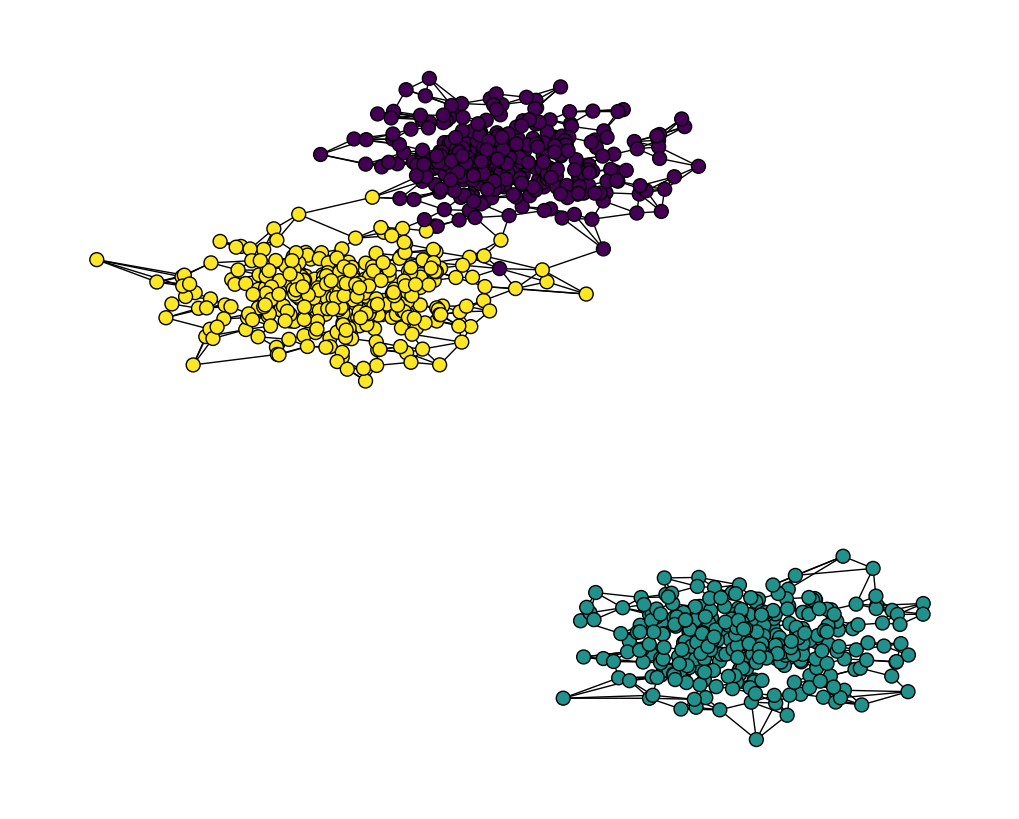

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import networkx as nx
k = 5

nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, indices = nbrs.kneighbors(X)

G = nx.Graph()
G.add_nodes_from(range(X.shape[0]))

for i in range(X.shape[0]):
    for j in indices[i][1:]:
        G.add_edge(i, j)

plt.figure(figsize=(10, 8))

pos = {i: (X[i, 0], X[i, 1]) for i in range(X.shape[0])}

nx.draw(G, pos,
        node_color=y, node_size = 100,
        edgecolors='black')

plt.show()


# Сверточная нейронная сеть для предсказания y по X

In [4]:
import torch
import torch.nn.functional as F
from torch.nn import Conv1d, Linear, BatchNorm1d, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


In [5]:
def accuracy(pred_y, y):
  return ((pred_y == y).sum() / len(y)).item()

In [6]:
class CNN(torch.nn.Module):
  def __init__(self, dim_in, dim_h, dim_out):
    super().__init__()
    self.conv1 = Conv1d(1, dim_h, kernel_size=2, padding=1)
    self.bn1 = BatchNorm1d(dim_h)
    self.conv2 = Conv1d(dim_h, dim_h*2, kernel_size=2, padding=1)
    self.bn2 = BatchNorm1d(dim_h*2)
    self.linear1 = Linear(dim_h*2, dim_h*4)
    self.dropout = Dropout(0.5)
    self.linear2 = Linear(dim_h*4, dim_out)

  def forward(self, x):
    x = x.unsqueeze(1)
    h = self.conv1(x)
    h = self.bn1(h)
    h = torch.relu(h)
    h = F.max_pool1d(h, kernel_size=2)
    h = self.conv2(h)
    h = self.bn2(h)
    h = torch.relu(h)
    h = F.max_pool1d(h, kernel_size=2)
    h = h.view(h.size(0), -1)
    h = self.linear1(h)
    h = torch.relu(h)
    h = self.dropout(h)
    h = self.linear2(h)
    return F.log_softmax(h, dim=1)

  def fit(self, X_train, y_train, X_val, y_val, epochs):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=5e-4)
    self.train()
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.LongTensor(y_train)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.LongTensor(y_val)

    for epoch in range(epochs+1):
      optimizer.zero_grad()
      out = self.forward(X_train_t)
      loss = criterion(out, y_train_t)
      acc = accuracy(out.argmax(dim=1), y_train_t)
      loss.backward()
      optimizer.step()
      if(epoch % 20 == 0):
        self.eval()
        with torch.no_grad():
          val_out = self.forward(X_val_t)
          val_loss = criterion(val_out, y_val_t)
          val_acc = accuracy(val_out.argmax(dim=1), y_val_t)
        self.train()
        print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

  @torch.no_grad()
  def test(self, X_test, y_test):
    self.eval()
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.LongTensor(y_test)
    out = self(X_test_t)
    acc = accuracy(out.argmax(dim=1), y_test_t)
    return acc

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_val)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"Количество классов: {len(np.unique(y))}")

Размер обучающей выборки: 640
Размер валидационной выборки: 160
Размер тестовой выборки: 200
Количество классов: 3


In [8]:
cnn = CNN(dim_in=2, dim_h=16, dim_out=3)
print(cnn)

CNN(
  (conv1): Conv1d(1, 16, kernel_size=(2,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(16, 32, kernel_size=(2,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear1): Linear(in_features=32, out_features=64, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (linear2): Linear(in_features=64, out_features=3, bias=True)
)


In [9]:
cnn.fit(X_train, y_train, X_val, y_val, epochs=100)

Epoch   0 | Train Loss: 1.193 | Train Acc: 25.00% | Val Loss: 1.08 | Val Acc: 33.13%
Epoch  20 | Train Loss: 0.019 | Train Acc: 99.37% | Val Loss: 0.02 | Val Acc: 99.37%
Epoch  40 | Train Loss: 0.006 | Train Acc: 99.84% | Val Loss: 0.03 | Val Acc: 99.37%
Epoch  60 | Train Loss: 0.007 | Train Acc: 99.69% | Val Loss: 0.05 | Val Acc: 98.75%
Epoch  80 | Train Loss: 0.003 | Train Acc: 99.84% | Val Loss: 0.05 | Val Acc: 98.75%
Epoch 100 | Train Loss: 0.003 | Train Acc: 100.00% | Val Loss: 0.06 | Val Acc: 98.75%


In [10]:
test_acc = cnn.test(X_test, y_test)
print(f'\nТочность на тестовой выборке: {test_acc*100:.2f}%')


Точность на тестовой выборке: 99.50%


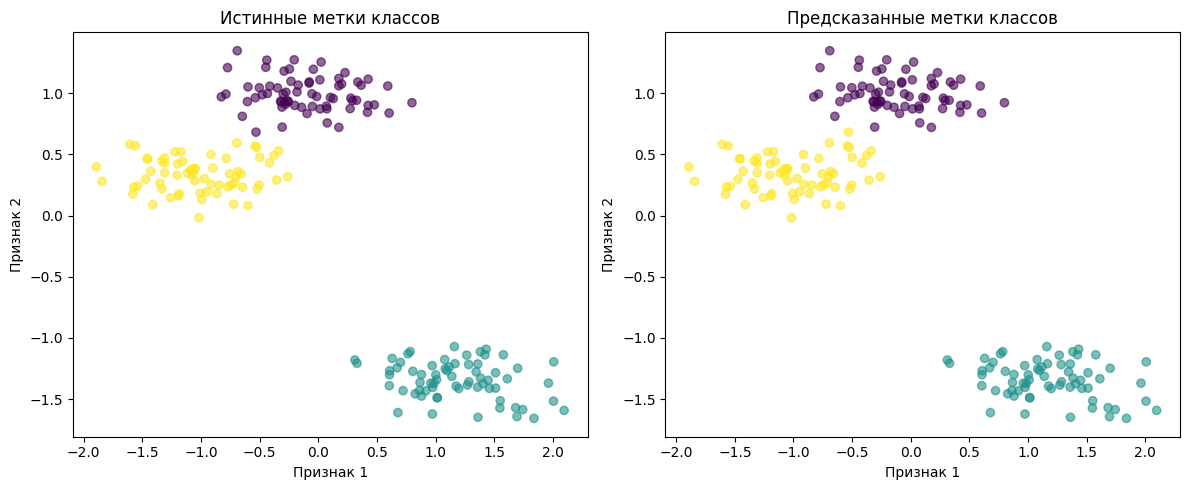

In [12]:
cnn.eval()
with torch.no_grad():
  X_test_t = torch.FloatTensor(X_test)
  predictions = cnn(X_test_t)
  predicted_classes = predictions.argmax(dim=1).cpu().numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', alpha=0.6)
plt.title('Истинные метки классов')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')


plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=predicted_classes, cmap='viridis', alpha=0.6)
plt.title('Предсказанные метки классов')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')


plt.tight_layout()
plt.show()
